| Dataset         | Vertices | Edges | BMSSP V1 | Dijkstra | BMSSP-V2 (Optimized) | Dijkstra (Optimized) |
| :-------------- | -------: | ----: | -------: | -------: | -------------------: | -------------------: |
| Stanford        |     281K |  2.3M |  1.0779s |  0.3447s |          **0.2141s** |              0.3171s |
| Google          |     916K |  5.1M |  2.6174s |  1.1571s |          **0.6392s** |              1.1297s |
| Pokec           |     1.6M | 30.6M | 24.1432s |  7.0684s |          **4.1297s** |              6.4779s |
| California      |     1.9M |  2.7M |  7.3192s |  2.2727s |          **1.9153s** |              2.1733s |
| LiveJournal     |     4.8M | 69.0M | 62.0967s | 18.1283s |          **9.5515s** |             16.4488s |
| WikiTalk        |     2.4M |    5M |  6.8408s |  3.5418s |          **1.5187s** |              3.3020s |
| TwitterCombined |     568M |  2.4M | 16.0902s |  4.5017s |          **0.0360s** |             14.9829s |

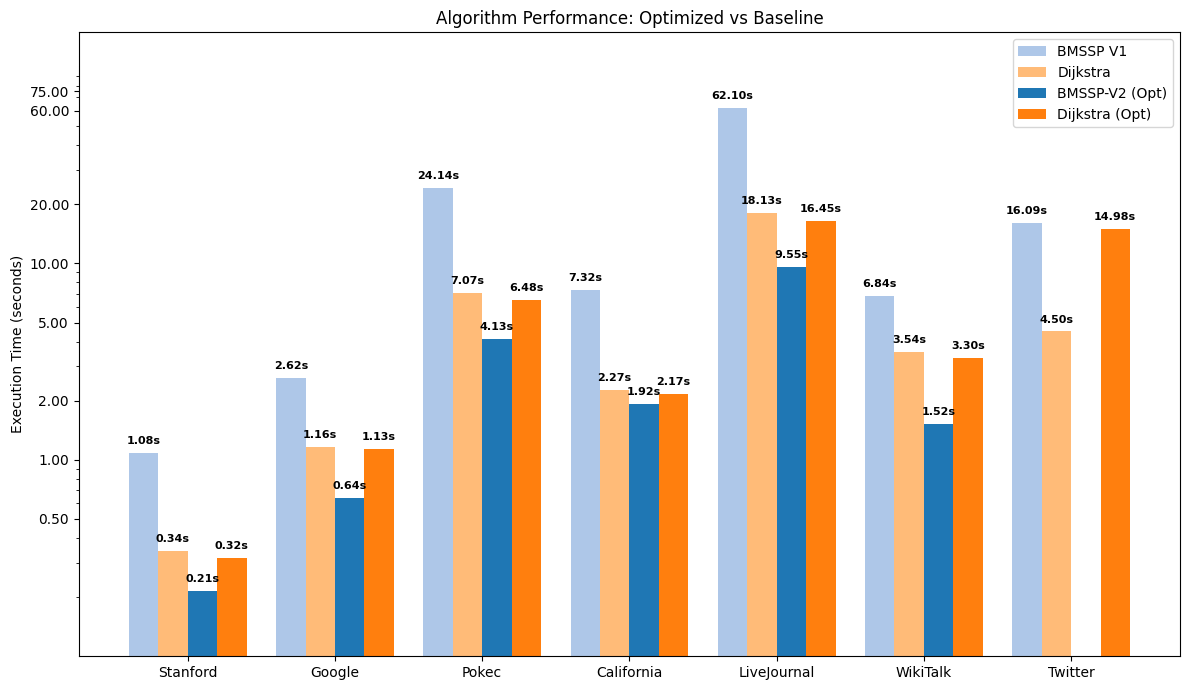

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd
import numpy as np

data = {
    'Dataset': ['Stanford', 'Google', 'Pokec', 'California', 'LiveJournal', 'WikiTalk', 'Twitter'],
    'BMSSP V1': [1.0779, 2.6174, 24.1432, 7.3192, 62.0967, 6.8408, 16.0902],
    'Dijkstra': [0.3447, 1.1571, 7.0684, 2.2727, 18.1283, 3.5418, 4.5017],
    'BMSSP-V2 (Optimized)': [0.2141, 0.6392, 4.1297, 1.9153, 9.5515, 1.5187, 0.0360],
    'Dijkstra (Optimized)': [0.3171, 1.1297, 6.4779, 2.1733, 16.4488, 3.3020, 14.9829]
}

df = pd.DataFrame(data)

x = np.arange(len(df['Dataset']))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - 1.5*width, df['BMSSP V1'], width, label='BMSSP V1', color='#aec7e8')
rects2 = ax.bar(x - 0.5*width, df['Dijkstra'], width, label='Dijkstra', color='#ffbb78')
rects3 = ax.bar(x + 0.5*width, df['BMSSP-V2 (Optimized)'], width, label='BMSSP-V2 (Opt)', color='#1f77b4')
rects4 = ax.bar(x + 1.5*width, df['Dijkstra (Optimized)'], width, label='Dijkstra (Opt)', color='#ff7f0e')

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0, 0.02, 0.5, 1, 2, 5, 10, 20, 60, 75])

# 2. ADD DATA LABELS
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

for r in [rects1, rects2, rects3, rects4]:
    autolabel(r)

ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Algorithm Performance: Optimized vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(df['Dataset'])
ax.legend()
plt.ylim(0.1, 150)
plt.tight_layout()
plt.show()


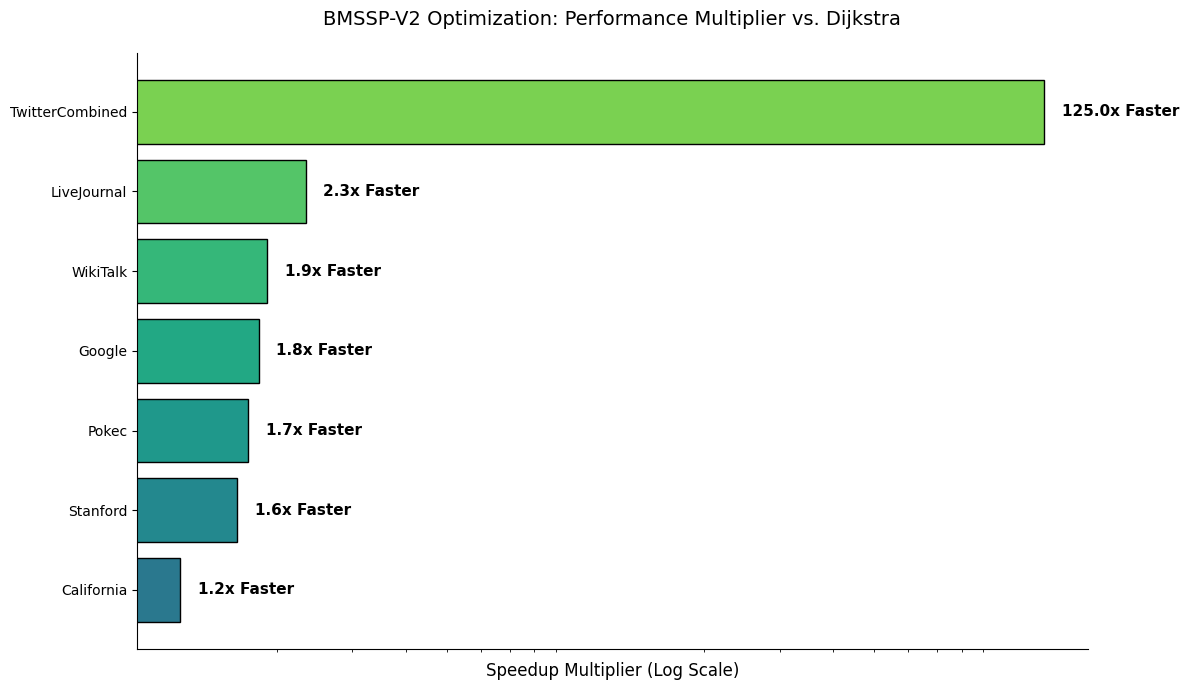

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["Stanford", "Google", "Pokec", "California", "WikiTalk", "LiveJournal", "TwitterCombined"]
v2_times = np.array([0.2141, 0.6392, 4.1297, 1.9153, 9.5515, 1.5187, 0.0360])
dijkstra_times = np.array([0.3447, 1.1571, 7.0684, 2.2727, 18.1283, 3.5418, 4.5017])

# Calculate Speedup
speedup = dijkstra_times / v2_times

# Sort by speedup for visual flow
idx = np.argsort(speedup)
datasets = [datasets[i] for i in idx]
speedup = speedup[idx]

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(datasets))) # Nice gradient
bars = ax.barh(datasets, speedup, color=colors, edgecolor='black')

# Log scale makes the massive range visible
ax.set_xscale('log')
ax.set_xticks([])
ax.set_xticklabels([])

# Add "X Faster" labels
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.1, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}x Faster', va='center', fontweight='bold', fontsize=11)

# Clean up styling
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Speedup Multiplier (Log Scale)', fontsize=12)
ax.set_title('BMSSP-V2 Optimization: Performance Multiplier vs. Dijkstra', fontsize=14, pad=20)
plt.tight_layout()
plt.show()
